#  Análise Exploratória de Dados (EDA): Goodreads Dataset

In [12]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [13]:
caminho = '../data/interim/books/goodreads_books_cleaned.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10965, 12)


---
## Análise Univariada

In [14]:
df_colunas = pd.DataFrame({
    "coluna": df_books.columns,
    "dtype_pandas": df_books.dtypes.values,
    "tipo_real": [
        df_books[col].map(type)[0].__name__
        if not df_books[col].dropna().empty else None
        for col in df_books.columns
    ]
})

display(tb.estilizar_tabela(
    df=df_colunas,
    caption="Colunas do dataframe"
))

,coluna,dtype_pandas,tipo_real
0,book_id,int64,int
1,title,object,str
2,Author,object,str
3,average_rating,float64,float
4,isbn,object,str
5,language_code,object,str
6,num_pages,int64,int
7,ratings_count,int64,int
8,text_reviews_count,int64,int
9,publication_date,datetime64[ns],Timestamp


### Colunas Numéricas

In [15]:
# Análisado Colunas Numéricas Individualmente
resumo_cols_numericas = mt.numeric_summary(df_books)
display(
    tb.estilizar_tabela(
        resumo_cols_numericas,
        caption="Relatorio colunas numéricas"
    ).format("{:,.2f}")
)

,mean,median,std,min,max,iqr,skew,kurtosis,outlier_count,outlier_%
column,,,,,,,,,,
book_id,"21,283.36","20,235.00","13,080.32",1.00,"45,641.00","21,796.00",0.15,-1.14,0.00,0.00
ratings_count,"18,201.30",784.00,"113,286.10",1.00,"4,597,666.00","5,035.00",17.57,436.11,"1,686.00",15.38
text_reviews_count,549.85,49.00,"2,594.29",0.00,"94,265.00",235.00,16.07,391.20,"1,591.00",14.51
num_pages,338.04,301.00,240.89,0.00,"6,576.00",220.00,4.33,63.48,557.00,5.08
average_rating,3.94,3.96,0.29,2.00,5.00,0.35,-0.57,1.95,233.00,2.12


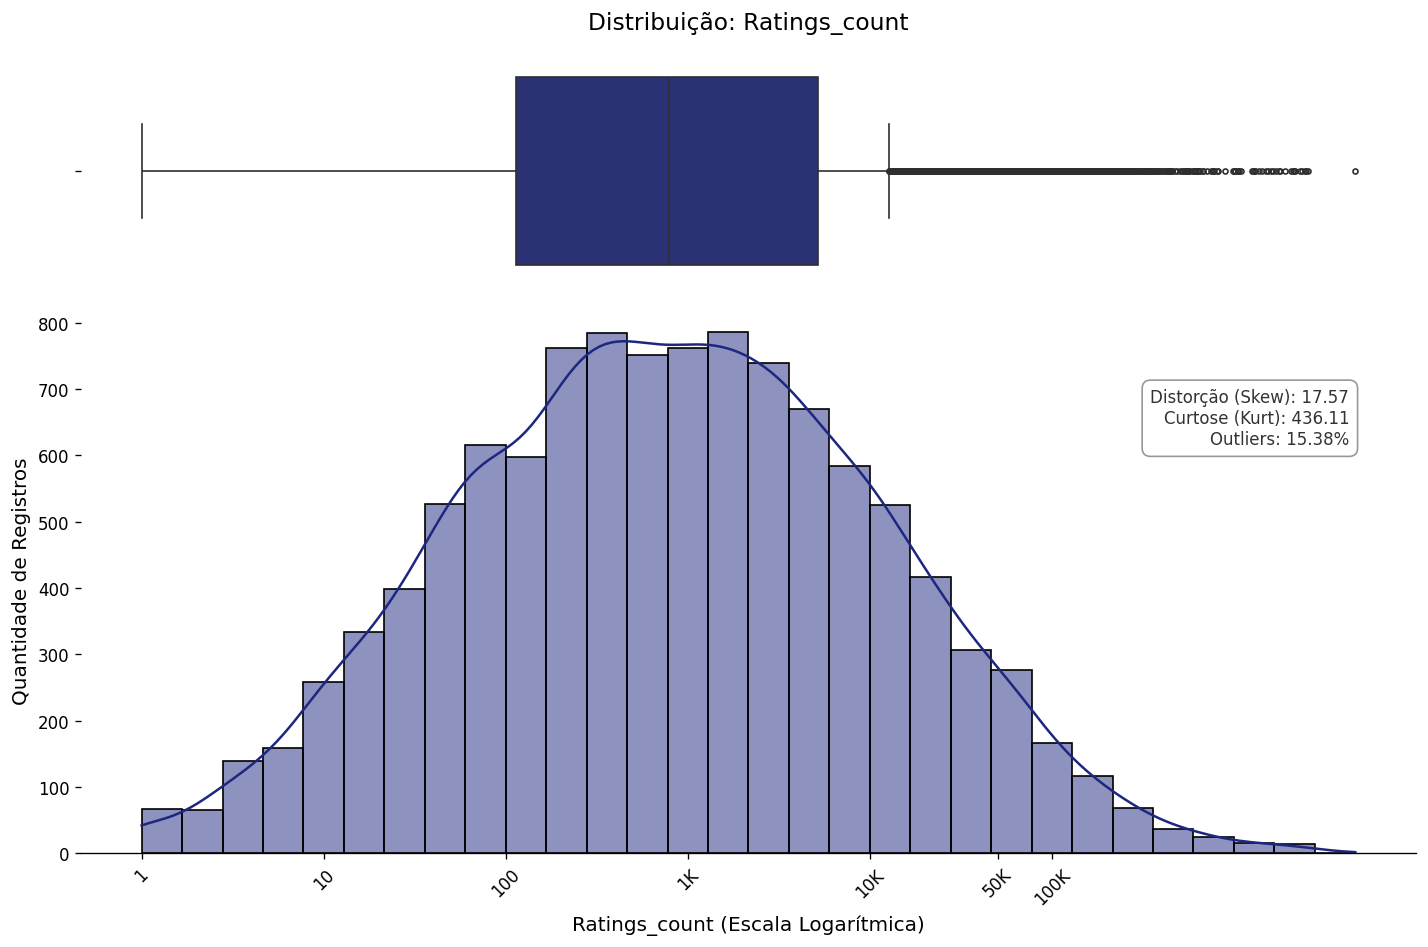

In [16]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='ratings_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

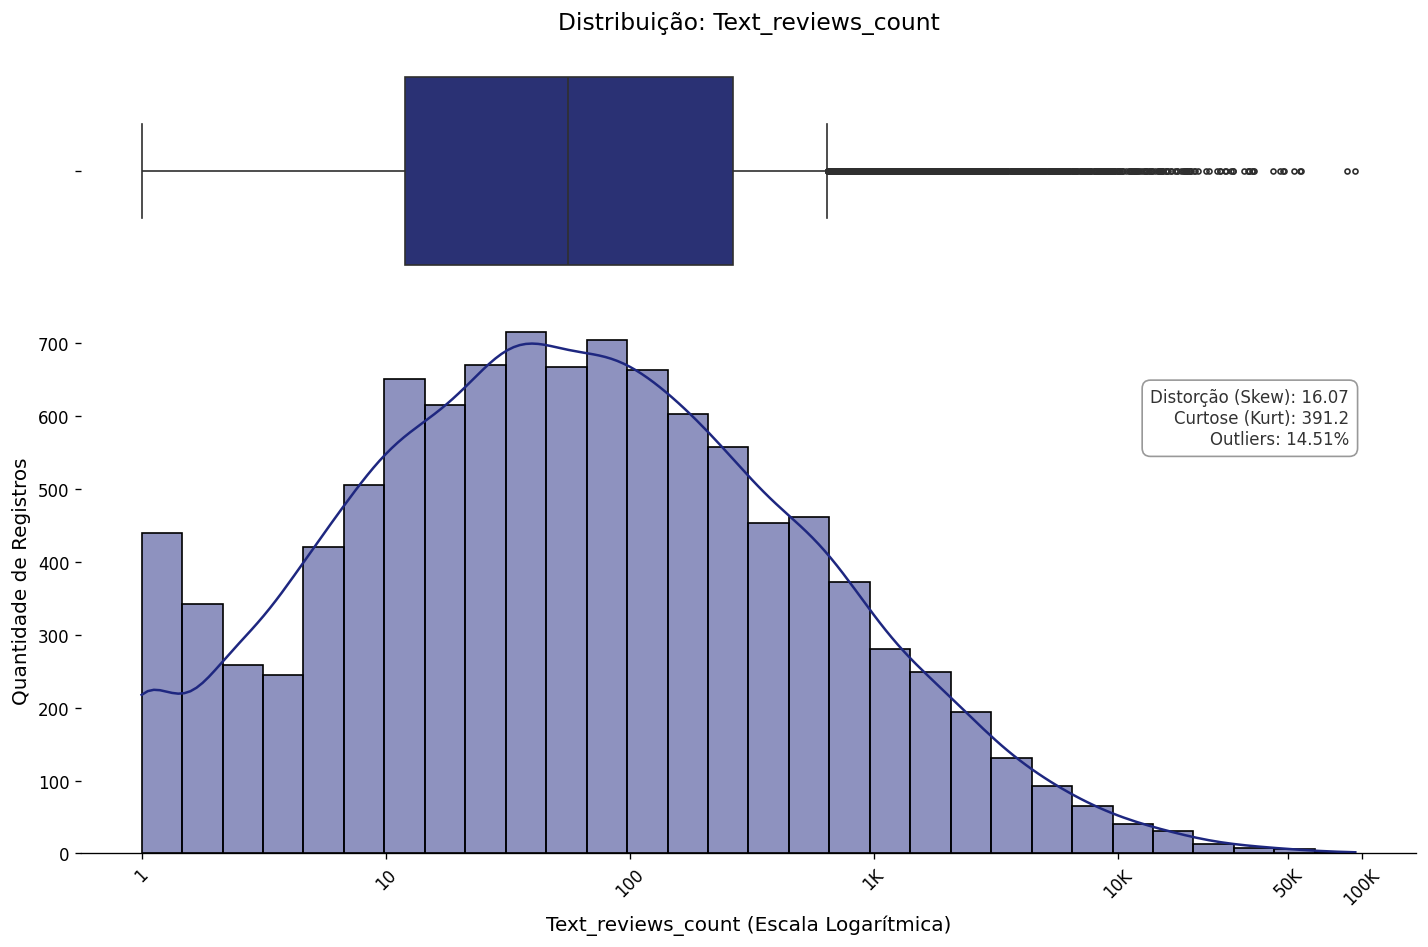

In [17]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='text_reviews_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

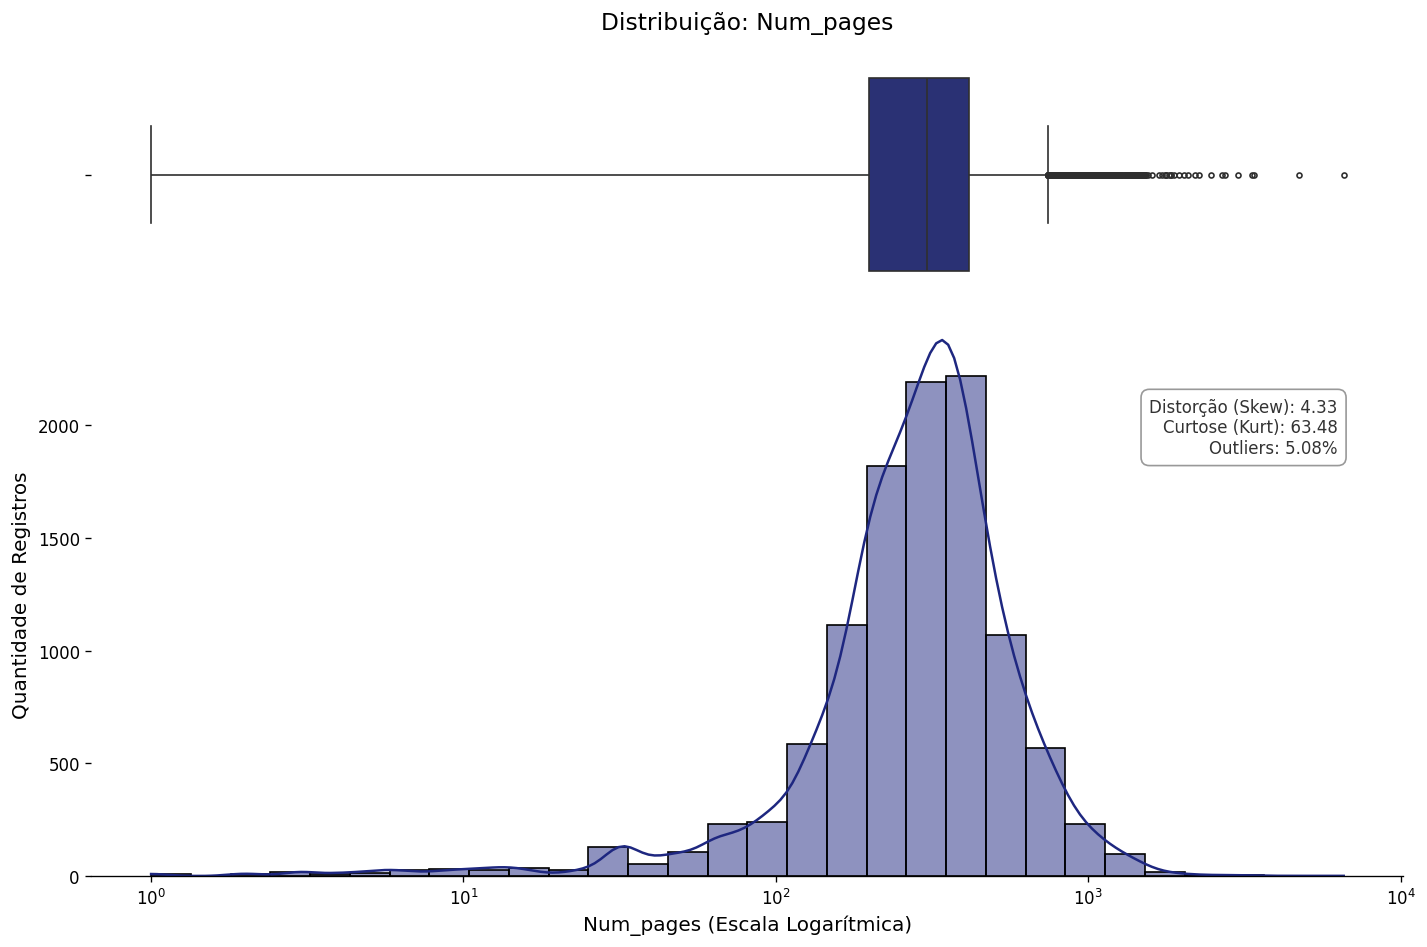

In [18]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='num_pages', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True
)

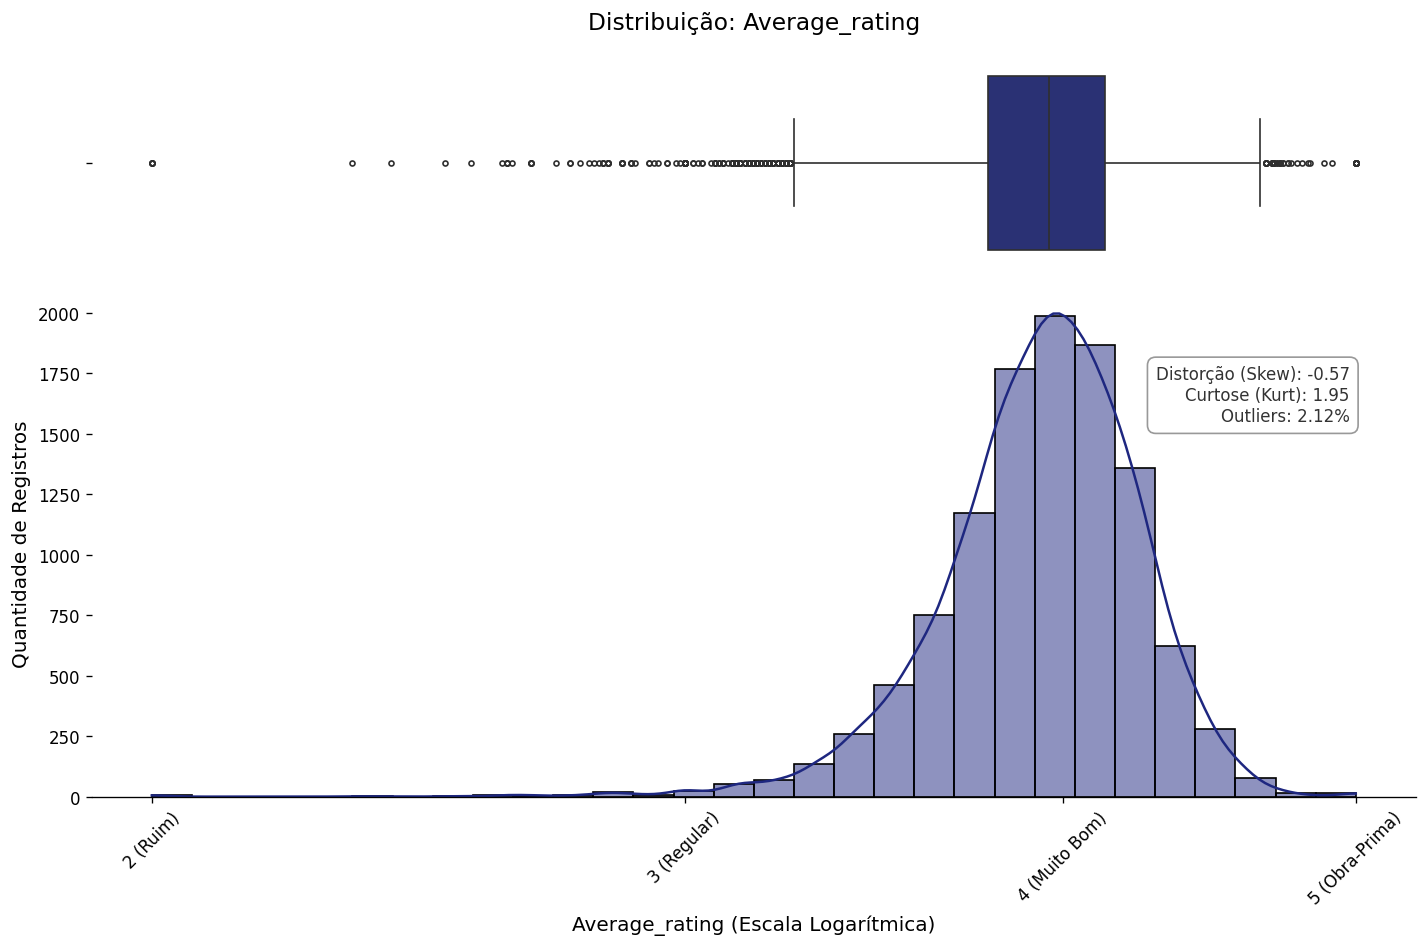

In [19]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='average_rating', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='nota_5'
)

### Colunas Categoricas

In [20]:
# Análisado Colunas Categorical Individualmente
resumo_cols_categoricas = mt.categorical_summary(df_books)
display(
    tb.estilizar_relatorio_categorias(
        resumo_cols_categoricas,
        caption="Relatorio colunas categoricas"
    )
)

,total_valid_rows,unique_categories,entropy_norm,top_values_count,top_values_pct_%
column,,,,,
isbn,10965,10965,1.000000,• 0439785960 (1)• 0439358078 (1)• 0439554896 (1)• 043965548X (1)• 0439682584 (1)• 0976540606 (1)• 0439827604 (1)• 0517226952 (1)• 0345453743 (1)• 1400052920 (1),• 0439785960 (0.0%)• 0439358078 (0.0%)• 0439554896 (0.0%)• 043965548X (0.0%)• 0439682584 (0.0%)• 0976540606 (0.0%)• 0439827604 (0.0%)• 0517226952 (0.0%)• 0345453743 (0.0%)• 1400052920 (0.0%)
title,10965,10196,0.995100,• The Iliad (9)• The Brothers Karamazov (9)• Anna Karenina (8)• The Odyssey (8)• Gulliver's Travels (8)• 'Salem's Lot (8)• The Picture of Dorian Gray (7)• A Midsummer Night's Dream (7)• Collected Stories (6)• The Great Gatsby (6),• The Iliad (0.1%)• The Brothers Karamazov (0.1%)• Anna Karenina (0.1%)• The Odyssey (0.1%)• Gulliver's Travels (0.1%)• 'Salem's Lot (0.1%)• The Picture of Dorian Gray (0.1%)• A Midsummer Night's Dream (0.1%)• Collected Stories (0.1%)• The Great Gatsby (0.1%)
Author,10965,6528,0.954100,• Stephen King (40)• P.G. Wodehouse (40)• Rumiko Takahashi (38)• Orson Scott Card (35)• Agatha Christie (33)• Piers Anthony (30)• Mercedes Lackey (29)• Sandra Brown (29)• Dick Francis (28)• Margaret Weis/Tracy Hickman (23),• Stephen King (0.4%)• P.G. Wodehouse (0.4%)• Rumiko Takahashi (0.3%)• Orson Scott Card (0.3%)• Agatha Christie (0.3%)• Piers Anthony (0.3%)• Mercedes Lackey (0.3%)• Sandra Brown (0.3%)• Dick Francis (0.3%)• Margaret Weis/Tracy Hickman (0.2%)
publisher,10965,2227,0.844700,• Vintage (318)• Penguin Books (261)• Penguin Classics (184)• Mariner Books (149)• Ballantine Books (144)• HarperCollins (112)• Harper Perennial (112)• Pocket Books (111)• Bantam (110)• VIZ Media LLC (88),• Vintage (2.9%)• Penguin Books (2.4%)• Penguin Classics (1.7%)• Mariner Books (1.4%)• Ballantine Books (1.3%)• HarperCollins (1.0%)• Harper Perennial (1.0%)• Pocket Books (1.0%)• Bantam (1.0%)• VIZ Media LLC (0.8%)
genres,10965,852,0.745000,"• Fiction (6852)• Classics (3321)• Nonfiction (3073)• Literature (2840)• Fantasy (2541)• Novels (2522)• Historical,Historical Fiction (1783)• Audiobook (1634)• Mystery (1596)• History (1583)","• Fiction (62.5%)• Classics (30.3%)• Nonfiction (28.0%)• Literature (25.9%)• Fantasy (23.2%)• Novels (23.0%)• Historical,Historical Fiction (16.3%)• Audiobook (14.9%)• Mystery (14.6%)• History (14.4%)"
language_code,10965,25,0.238200,• eng (8778)• en-US (1403)• en-GB (214)• spa (210)• fre (139)• ger (95)• jpn (45)• mul (19)• zho (14)• por (10),• eng (80.1%)• en-US (12.8%)• en-GB (2.0%)• spa (1.9%)• fre (1.3%)• ger (0.9%)• jpn (0.4%)• mul (0.2%)• zho (0.1%)• por (0.1%)


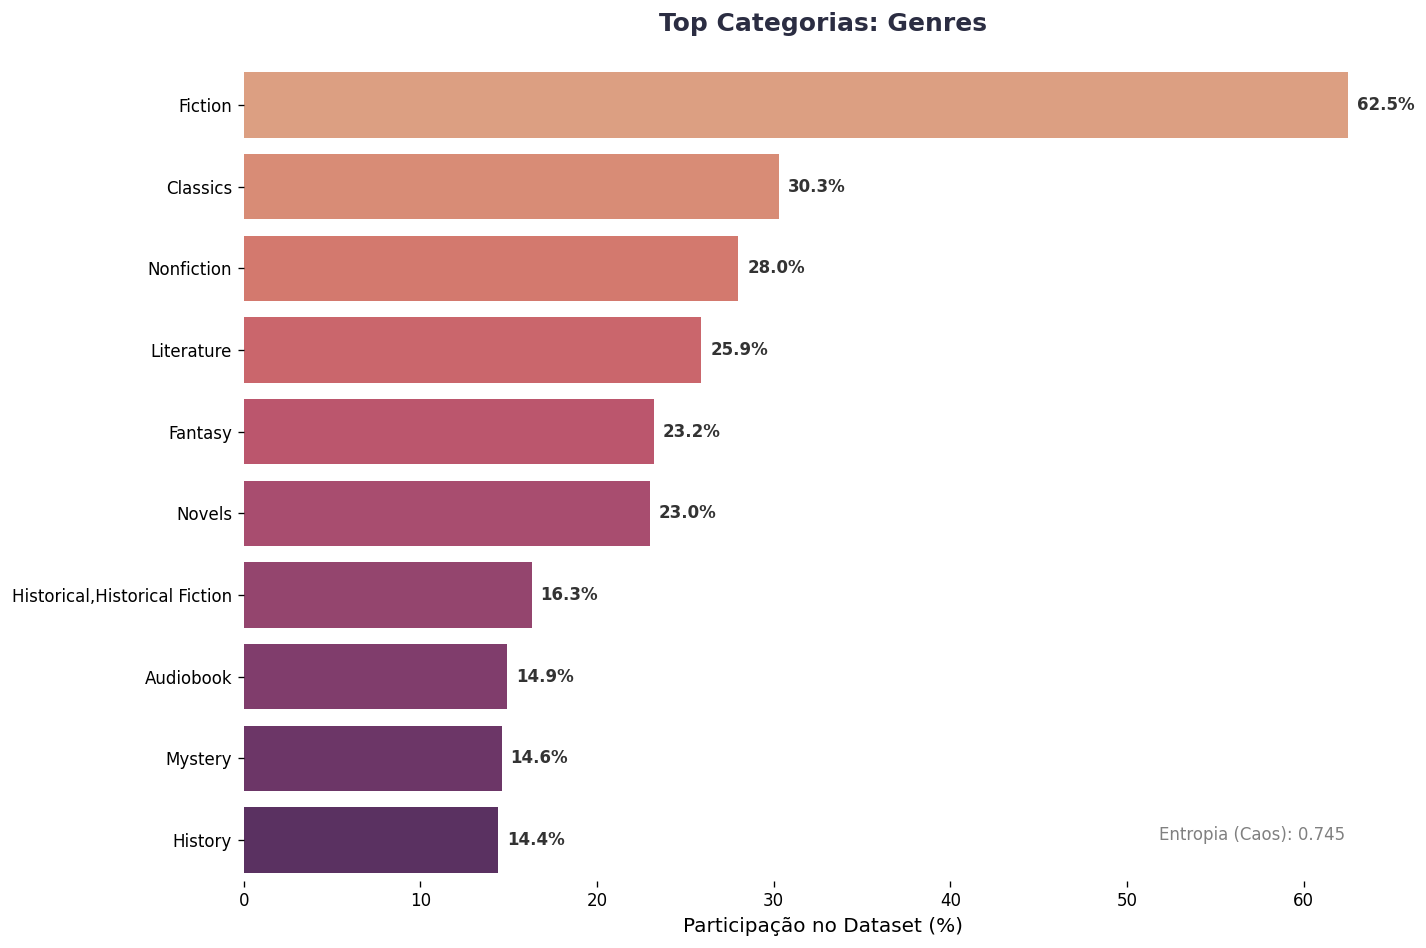

In [21]:
graf.grafico_top_categorias(df_books, 'genres', resumo_cols_categoricas)

## Avaliação de Identificadores Alternativos e Regionalização
O dataset possui colunas voltadas para a identificação comercial e categorização demográfica das obras. Para otimizar a estrutura final, foi realizada uma análise de necessidade e sobreposição dessas variáveis.

### Observações Identificadas:

- Potencial Analítico de Idioma: A variável categórica language_code (idioma original do livro) apresenta uma rica diversidade de registros. Esta dimensão tem alto valor estratégico, pois será o pilar para futuras análises de regionalização, permitindo segmentar o comportamento e a popularidade dos tropos literários por mercado linguístico.

- Distribuição Orgânica das Notas (average_rating): A plotagem do histograma serviu como prova visual da eficácia da limpeza de dados. A distribuição resultante apresenta uma assimetria negativa (Left-Skewed), com a vasta maioria do engajamento orgânico concentrada na faixa de 3.5 a 4.2. Avaliações perfeitas (5.0) ou muito baixas (menores que 2.0) mostraram-se estatisticamente raras na plataforma.

- Engajamento de Cauda Longa (ratings_count): A análise de popularidade demonstrou um comportamento clássico de Cauda Longa. Foi necessário o uso de uma escala logarítmica para contornar a distorção visual gerada por um grupo ínfimo de best-sellers globais, revelando que a grande maioria do acervo literário concentra-se na faixa de nicho (entre 100 e 10.000 avaliações).

### Decisão e Tratamento:
Aplicando o princípio de redução de dimensionalidade e eficiência de armazenamento, a coluna isbn13 será excluída (dropada), eliminando a redundância. A coluna isbn tradicional será mantida como o identificador comercial padrão caso sejam necessários cruzamentos futuros (como agregações com datasets de livrarias externas). A coluna language_code será integralmente preservada para viabilizar os filtros demográficos no Dashboard.

Por fim, os gráficos de validação visual gerados nesta etapa (histogramas de distribuição em escala linear e logarítmica, e barras de proporção) serão mantidos no notebook como documentação formal da EDA (Exploratory Data Analysis), servindo de garantia técnica da higienização dos dados antes da carga no banco de dados SQLite.

---

## Exploração de Outliers e Anomalias Numéricas

Nesta etapa, o objetivo é auditar a base de dados em busca de duas frentes: **falhas de integridade física** (erros do sistema) e **anomalias orgânicas** (comportamento atípico, porém real, de leitores e obras).

In [22]:
# Verifica quais valores são menores que zero (< 0)

display(tb.estilizar_tabela(
    df=(df_clean.select_dtypes(include='number') < 0)
        .sum()
        .to_frame(name='contagem'
    ),
    caption="Quantidade de valores impossíveis (negativos) por coluna:"
))

NameError: name 'df_clean' is not defined

In [ ]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_clean.select_dtypes(include='number')
        .corr()['ratings_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação')
))

,Correlação
ratings_count,1.000000
text_reviews_count,0.865929
average_rating,0.041397
num_pages,0.033537
isbn13,0.004998
Book Id,-0.077133


(0.0, 304324.1600000041)

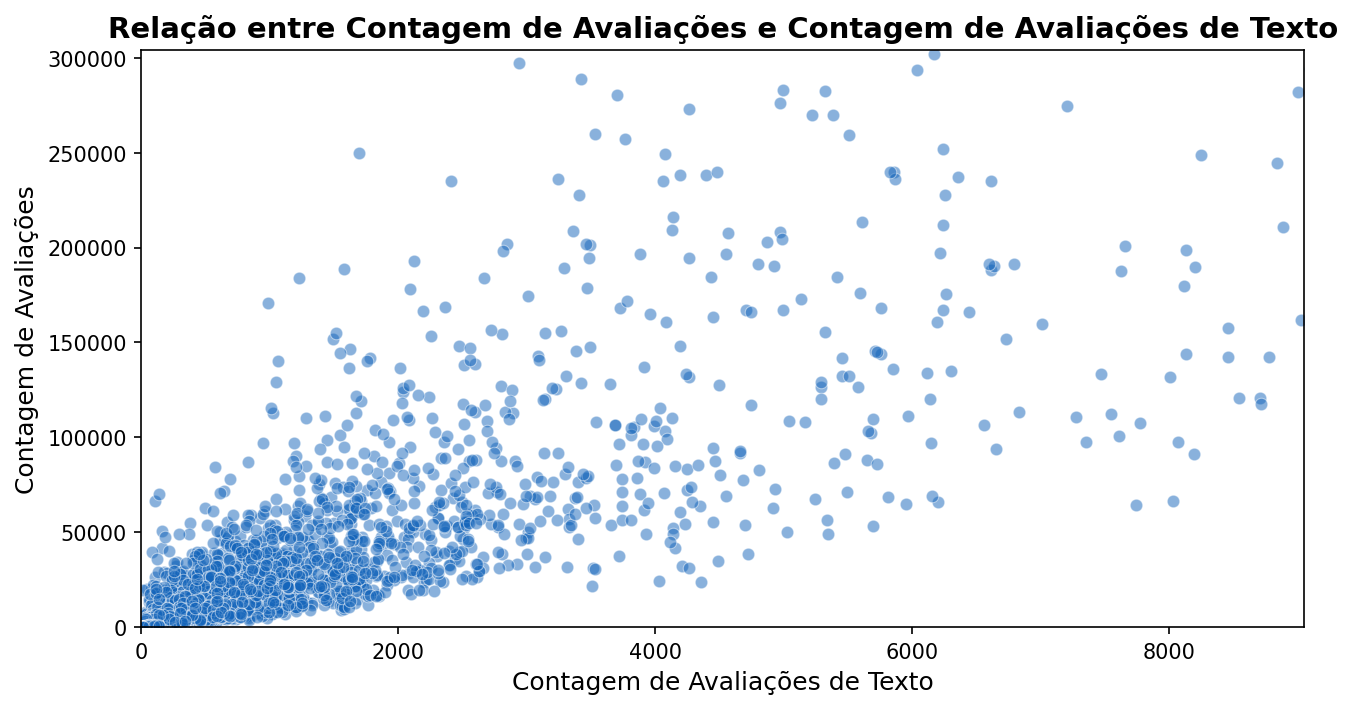

In [ ]:
plt.figure(figsize=(10, 5), dpi=150)
sns.scatterplot(
    data=df_clean,
    x='text_reviews_count',
    y='ratings_count',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Contagem de Avaliações de Texto', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações de Texto', fontsize=12)
plt.ylabel('Contagem de Avaliações', fontsize=12)

plt.xlim(0, df_clean['text_reviews_count'].quantile(0.99))
plt.ylim(0, df_clean['ratings_count'].quantile(0.99))

In [ ]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_clean
        .select_dtypes(include='number')
        .corr()['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação')
))

,Correlação
average_rating,1.000000
num_pages,0.172264
ratings_count,0.041397
text_reviews_count,0.034173
isbn13,-0.011123
Book Id,-0.038800


(0.0, 6.0)

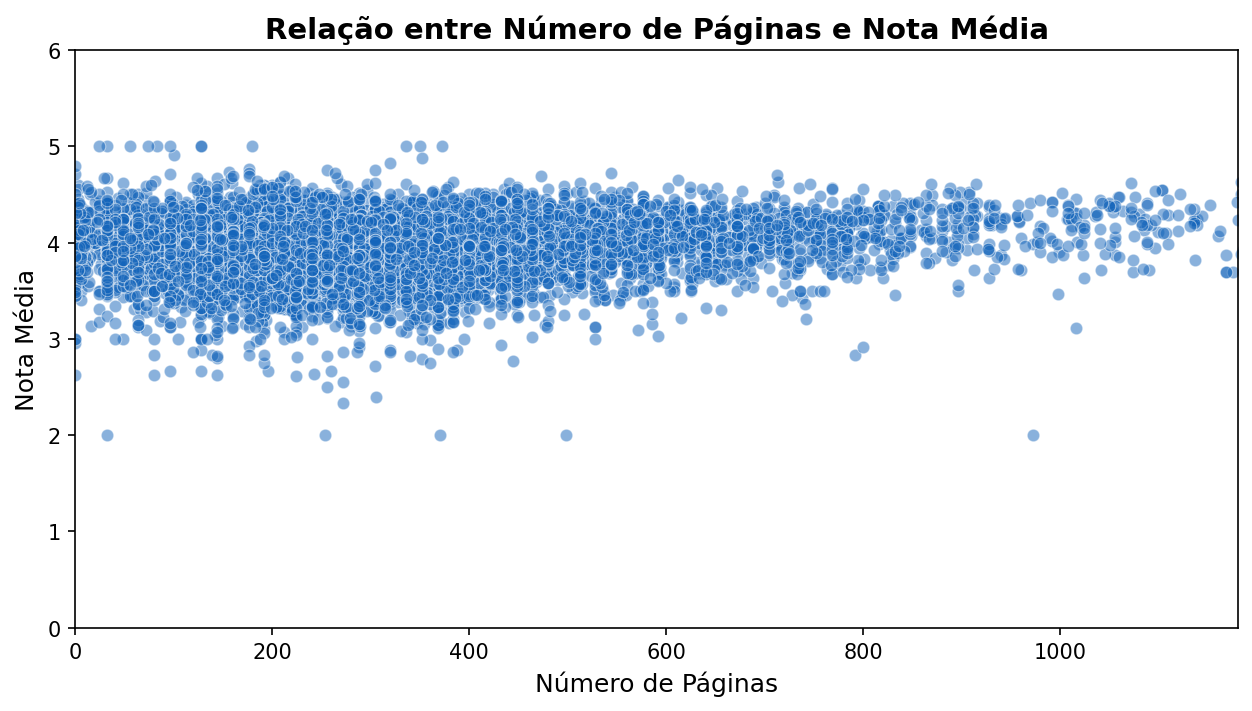

In [ ]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_clean,
    x='num_pages',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)

plt.title('Relação entre Número de Páginas e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_clean['num_pages'].quantile(0.99))
plt.ylim(0, 6)

(0.0, 6.0)

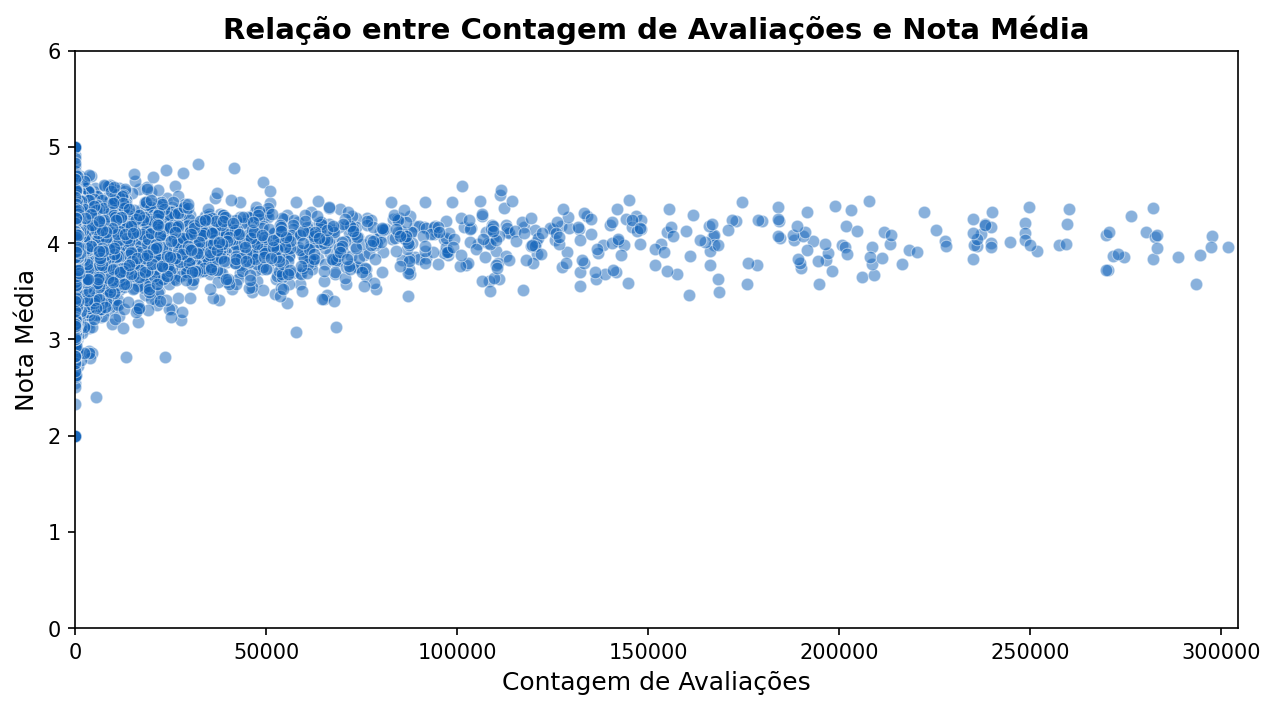

In [ ]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_clean,
    x='ratings_count',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_clean['ratings_count'].quantile(0.99))
plt.ylim(0, 6)


In [ ]:
# Verificando a distribuição dos livros com pouquíssimos votos

display(tb.estilizar_tabela(
    df=df_clean[df_clean['ratings_count'] <= 10]['ratings_count']
        .value_counts()
        .sort_index()
        .to_frame(name='Contagem'),
    caption="Quantidade de livros por número de votos (de 0 a 10):"
))

# Verificando especificamente quem tem apenas 1 voto
apenas_um = (df_clean['ratings_count'] == 1).sum()
print(f"\nLivros que possuem exatamente 1 voto: {apenas_um}")

,Contagem
ratings_count,
1,67
2,65
3,76
4,63
5,52
6,53
7,54
8,54
9,55



Livros que possuem exatamente 1 voto: 67


In [ ]:
print(f"Total de livros com pouquíssimos votos: {
    df_clean[df_clean['ratings_count'] <= 10]['ratings_count']
        .values
        .sum()
}")

Total de livros com pouquíssimos votos: 3100


In [ ]:
media = df_clean[df_clean['ratings_count'] <= 10]['average_rating'].mean()

print(f"Média das notas dos livros com pouquíssimos votos (<= 10): {media:.2f}")

Média das notas dos livros com pouquíssimos votos (<= 10): 3.88


In [ ]:
media = df_clean[df_clean['ratings_count'] == 1]['average_rating'].mean()

print(f"Média das notas dos livros com apenas 1 voto: {media:.2f}")

Média das notas dos livros com apenas 1 voto: 3.78


### Observações Identificadas:

- Teste de Integridade Física (*Sanity Check*)

  - Antes de analisar distribuições, precisamos garantir que as variáveis numéricas respeitam os limites da realidade. Valores de páginas, quantidade de avaliações e notas não podem ser negativos. O objetivo aqui não é encontrar "livros ruins", mas detectar **corrompimento de dados na origem** — registros onde o próprio sistema de coleta falhou e gerou valores fisicamente impossíveis.

- Análise de Outliers Orgânicos

  - Com a base fisicamente íntegra, investigamos pontos fora da curva no **comportamento de engajamento da plataforma**. Diferente das anomalias físicas, outliers orgânicos são valores reais, mas estatisticamente extremos — eles existem porque o mundo é assim, não porque houve um erro.

  - Para identificá-los, analisamos visualmente as correlações entre as principais features numéricas por meio de *scatterplots*, técnica que permite enxergar tanto a tendência geral de uma relação quanto os pontos que fogem dela.

- Distribuição de Engajamento Mínimo

  - Após confirmar a ausência de erros físicos e compreender a natureza dos outliers orgânicos, foi realizado um terceiro diagnóstico: a análise do **limite inferior de engajamento estatístico**. A questão central aqui não é se o dado é real, mas se ele é *representativo o suficiente* para sustentar uma análise comparativa.

  - A análise de integridade revelou que não há registros com zero avaliações no dataset processado. Identificamos **67 obras com apenas 1 voto** (média de $3.78$) e **593 com menos de 10 votos** (média de $3.88$).

### Decisão e Tratamento:
  - O teste vetorial confirmou a ausência de valores negativos nas colunas numéricas, atestando a **integridade basal da extração**. O dataset passou por este crivo sem nenhuma violação lógica de domínio.

  -  Os pontos extremos identificados nos gráficos não representam erros sistêmicos, mas sim o fenômeno de **Cauda Longa literária** (*Long Tail*) — a coexistência de obras de altíssimo nicho com poucas resenhas e best-sellers globais com centenas de milhares de avaliações. Este é um comportamento esperado e genuíno de plataformas de conteúdo em larga escala. **Estes registros serão mantidos, pois refletem a realidade da plataforma.**
  
---

## Resumo Final Para Limpeza e Preparação

* **Estado Inicial:** O dataset bruto iniciou o processo com 12 colunas e 11.127 linhas.
* **Redução de Dimensionalidade:** A coluna `isbn13` será removida por ser estruturalmente redundante, mantendo-se apenas o identificador `isbn` principal.
* **Uniformização de Colunas** A coluna `Title` será editada para `title` para padronizala com os demais datasets. O mesmo ocorrerá com a coluna `Book Id` que se tornará `book_id`.
* **Tratamento de Nulos e Anomalias Numéricas:**
  * Os registros com valores ausentes na coluna `genres` serão descartados.
  * Obras com inconsistência de engajamento (notas `0.00` ou `ratings_count` zerado) serão removidas para não distorcer as médias estatísticas do projeto.
  * *Impacto do corte:* Apenas 162 linhas removidas (1,45% de perda, volume estatisticamente irrelevante).
* **Integridade Física Confirmada:** O teste vetorial sobre todas as colunas numéricas confirmou a ausência de valores negativos, validando que o pipeline de extração não gerou corrompimento de dados na origem.
* **Outliers Orgânicos Mantidos:** Os pontos extremos de engajamento identificados nos scatterplots (como best-sellers globais) refletem a realidade da plataforma e o fenômeno de Cauda Longa literária. Nenhuma remoção foi aplicada sobre eles.
* **Engajamento Mínimo:** 593 obras com menos de 10 avaliações foram sinalizadas como `"Baixa Relevância Estatística"`. Esses registros serão preservados no dataset exploratório, mas um *threshold* de corte será aplicado nas etapas de análise correlacional para garantir que o `average_rating` represente uma opinião coletiva e não individual.
* **Engenharia de Features (Refatoração):** A coluna de texto bruto `genres` será processada, fatiada e "explodida" em formato de lista, atomizando os dados para suportar a arquitetura de banco de dados relacional.
* **Estado Final Esperado (Dado Ouro):** O dataset purificado resultará em um DataFrame final e íntegro de **10.965 linhas**, pronto para ser injetado nas tabelas do banco de dados SQLite (`tropes_literarios.db`).